# 🦠 COVID-19 Analytics Dashboard
### By Lisha Bhowmik
**Tech Stack:** Python | SQL | Power BI | Tableau | Looker Studio

In [5]:
# Cell 1 — Install Libraries
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [7]:
# Cell 2 — Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [8]:
# Cell 3 — Create Dataset
np.random.seed(42)

top10_countries = {
    'Country':   ['United States','Brazil','India','Russia','South Africa',
                  'Mexico','Peru','Chile','United Kingdom','Iran'],
    'Confirmed': [4_200_000, 2_500_000, 1_500_000, 820_000, 450_000,
                  395_000,  370_000,   340_000,   300_000,  280_000],
    'Deaths':    [145_000,   90_000,   34_000,   13_000,    7_000,
                   44_000,   17_000,    9_000,   46_000,   14_800],
    'Recovered': [1_900_000, 1_800_000, 980_000, 620_000, 330_000,
                   290_000,  240_000,  310_000,   4_000,  232_000],
}
df_top10 = pd.DataFrame(top10_countries)
df_top10['Active']        = df_top10['Confirmed'] - df_top10['Deaths'] - df_top10['Recovered']
df_top10['CFR_%']         = (df_top10['Deaths'] / df_top10['Confirmed'] * 100).round(2)
df_top10['Recovery_Rate'] = (df_top10['Recovered'] / df_top10['Confirmed'] * 100).round(2)

regions = {
    'Region':    ['Americas','Europe','South-East Asia','Eastern Mediterranean',
                  'Western Pacific','Africa'],
    'Confirmed': [8_700_000, 3_300_000, 1_900_000, 1_400_000, 310_000, 870_000],
    'Deaths':    [350_000,   210_000,   40_000,    35_000,    7_000,   16_000],
    'Recovered': [5_200_000, 1_900_000, 1_300_000, 1_100_000, 270_000, 650_000],
}
df_region = pd.DataFrame(regions)

wow_countries = ['Papua New Guinea','Gambia','Bahamas','Zimbabwe','Libya',
                 'Ethiopia','Botswana','Lesotho','Suriname','Costa Rica']
wow_rates     = [225, 190, 120, 55, 52, 50, 48, 46, 44, 40]
df_wow = pd.DataFrame({'Country': wow_countries, 'WoW_Growth_%': wow_rates})

dates = pd.date_range('2020-04-01', periods=90, freq='D')
base  = np.linspace(500_000, 16_480_000, 90)
noise = np.random.normal(0, 80_000, 90).cumsum()
df_ts = pd.DataFrame({
    'Date':      dates,
    'Confirmed': (base + noise).clip(0).astype(int),
    'Deaths':    ((base + noise) * 0.04).clip(0).astype(int),
    'Recovered': ((base + noise) * 0.55).clip(0).astype(int),
})
df_ts['Active'] = df_ts['Confirmed'] - df_ts['Deaths'] - df_ts['Recovered']

print('✅ Data created successfully!')
print(df_top10.head())

✅ Data created successfully!
         Country  Confirmed  Deaths  Recovered   Active  CFR_%  Recovery_Rate
0  United States    4200000  145000    1900000  2155000   3.45          45.24
1         Brazil    2500000   90000    1800000   610000   3.60          72.00
2          India    1500000   34000     980000   486000   2.27          65.33
3         Russia     820000   13000     620000   187000   1.59          75.61
4   South Africa     450000    7000     330000   113000   1.56          73.33


In [9]:
# Cell 4 — Data Cleaning
TOTAL_CONFIRMED = 16_480_000
TOTAL_DEATHS    =    654_036
TOTAL_RECOVERED =  9_470_000
TOTAL_ACTIVE    =  6_360_000

for df, name in [(df_top10,'Top10'), (df_region,'Regional'), (df_ts,'TimeSeries')]:
    df.drop_duplicates(inplace=True)
    print(f'[{name}] shape={df.shape}  nulls={df.isnull().sum().sum()}')

df_ts['Date'] = pd.to_datetime(df_ts['Date'])
print('\n✅ Data cleaned! Date range:', df_ts['Date'].min().date(), '→', df_ts['Date'].max().date())

[Top10] shape=(10, 7)  nulls=0
[Regional] shape=(6, 4)  nulls=0
[TimeSeries] shape=(90, 5)  nulls=0

✅ Data cleaned! Date range: 2020-04-01 → 2020-06-29


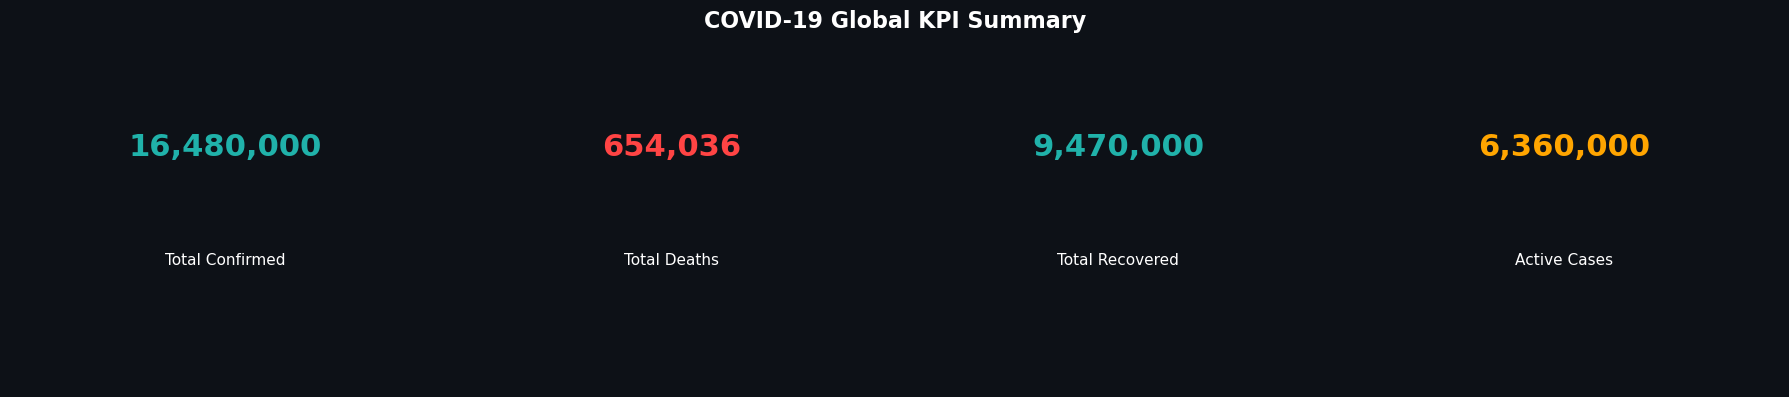

✅ KPI Cards saved!


In [10]:
# Cell 5 — KPI Cards Chart
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.patch.set_facecolor('#0D1117')

kpi_data = [
    ('Total Confirmed', TOTAL_CONFIRMED, '#20B2AA'),
    ('Total Deaths',    TOTAL_DEATHS,    '#FF4444'),
    ('Total Recovered', TOTAL_RECOVERED, '#20B2AA'),
    ('Active Cases',    TOTAL_ACTIVE,    '#FFA500'),
]

for ax, (label, value, color) in zip(axes, kpi_data):
    ax.set_facecolor('#161B22')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.72, f'{value:,.0f}', ha='center', va='center',
            fontsize=22, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.38, label, ha='center', va='center',
            fontsize=11, color='white', transform=ax.transAxes)

plt.suptitle('COVID-19 Global KPI Summary', color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_kpi_cards.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ KPI Cards saved!')

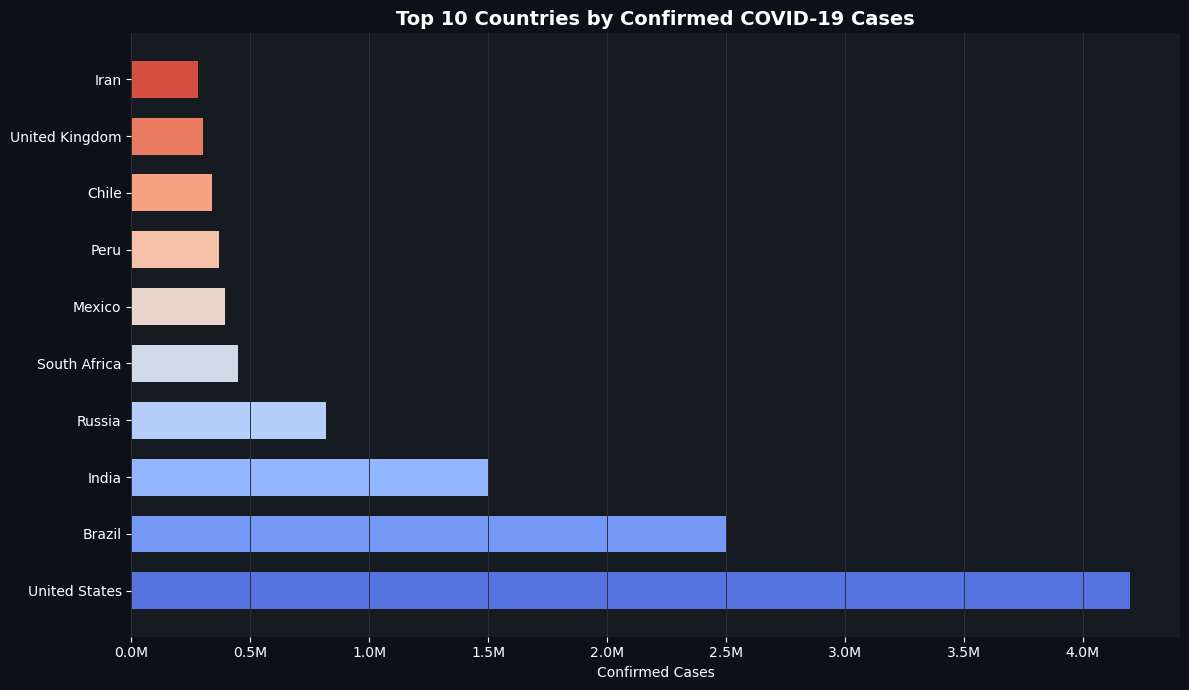

✅ Top 10 Countries chart saved!


In [11]:
# Cell 6 — Top 10 Countries Chart
palette = sns.color_palette('coolwarm', len(df_top10))
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

bars = ax.barh(df_top10['Country'], df_top10['Confirmed'], color=palette, height=0.65)
ax.set_xlabel('Confirmed Cases', color='white')
ax.set_title('Top 10 Countries by Confirmed COVID-19 Cases',
             color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for spine in ax.spines.values(): spine.set_visible(False)
ax.grid(axis='x', color='#2A2F3A', linewidth=0.7)

plt.tight_layout()
plt.savefig('outputs/02_top10_countries.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Top 10 Countries chart saved!')

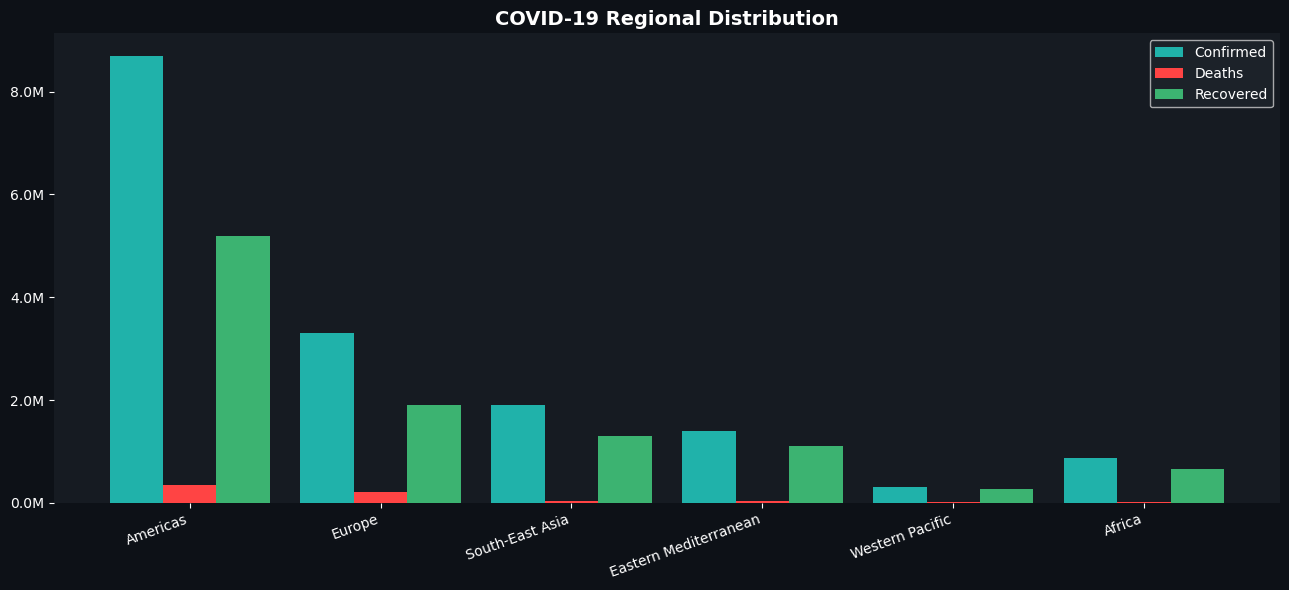

✅ Regional Distribution chart saved!


In [12]:
# Cell 7 — Regional Distribution Chart
x = np.arange(len(df_region))
w = 0.28
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

ax.bar(x - w, df_region['Confirmed'], w, label='Confirmed', color='#20B2AA')
ax.bar(x,     df_region['Deaths'],    w, label='Deaths',    color='#FF4444')
ax.bar(x + w, df_region['Recovered'], w, label='Recovered', color='#3CB371')

ax.set_xticks(x)
ax.set_xticklabels(df_region['Region'], rotation=20, ha='right', color='white')
ax.set_title('COVID-19 Regional Distribution', color='white', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(facecolor='#1E242C', labelcolor='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig('outputs/03_regional_distribution.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Regional Distribution chart saved!')

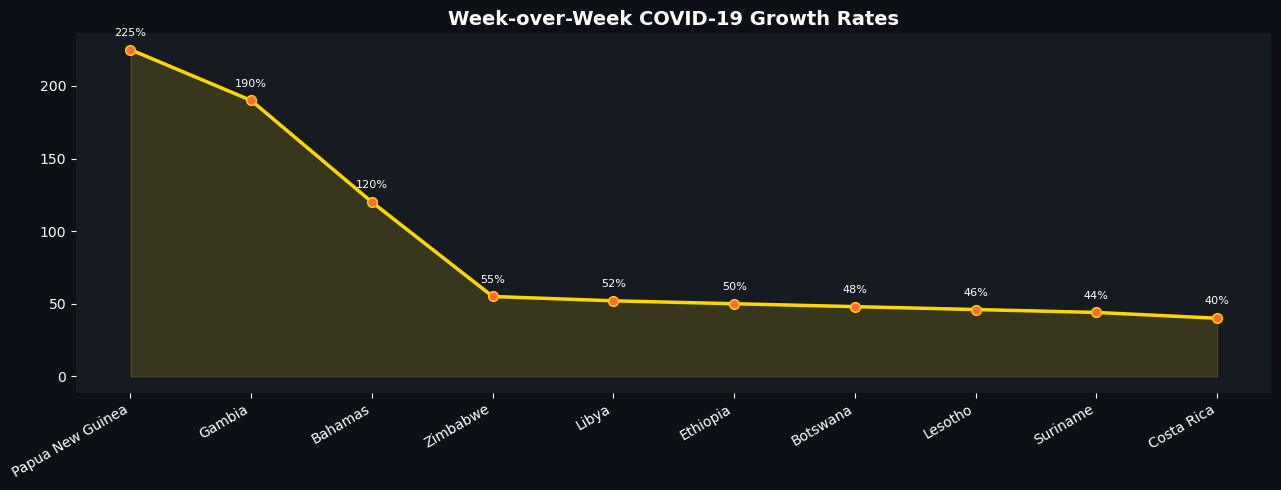

✅ WoW Growth chart saved!


In [13]:
# Cell 8 — Week-over-Week Growth Chart
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

ax.plot(df_wow['Country'], df_wow['WoW_Growth_%'],
        color='#FFD700', linewidth=2.5, marker='o',
        markersize=7, markerfacecolor='#FF6B35')
ax.fill_between(range(len(df_wow)), df_wow['WoW_Growth_%'], alpha=0.15, color='#FFD700')

for i, (c, v) in enumerate(zip(df_wow['Country'], df_wow['WoW_Growth_%'])):
    ax.annotate(f'{v}%', (i, v), textcoords='offset points',
                xytext=(0, 10), ha='center', color='white', fontsize=8)

ax.set_xticks(range(len(df_wow)))
ax.set_xticklabels(df_wow['Country'], rotation=30, ha='right', color='white')
ax.set_title('Week-over-Week COVID-19 Growth Rates', color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig('outputs/04_wow_growth.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ WoW Growth chart saved!')

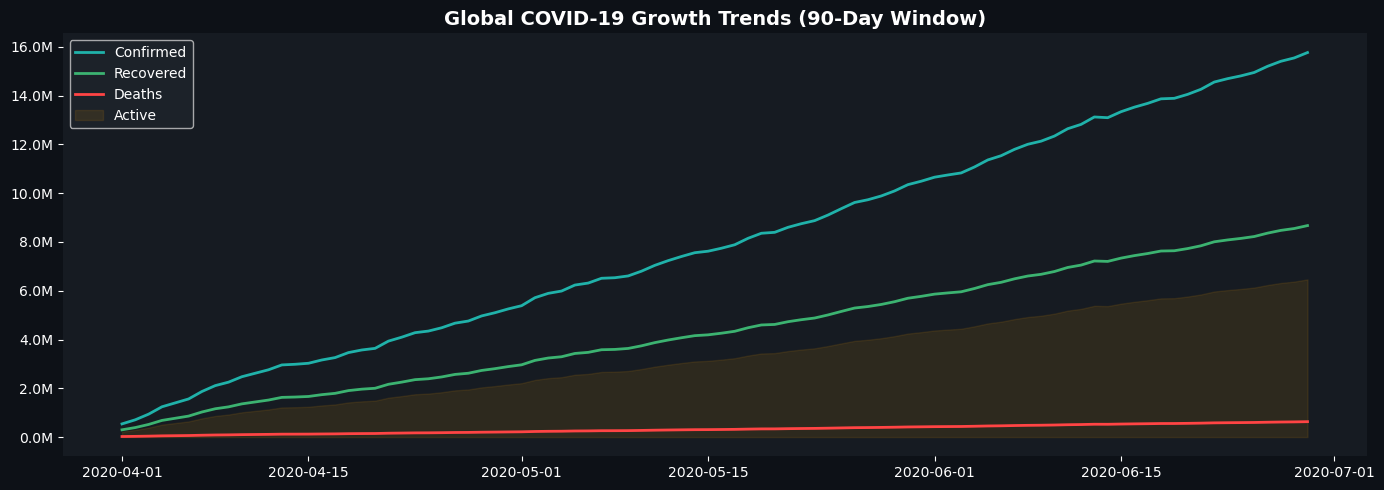

✅ Global Trend chart saved!


In [14]:
# Cell 9 — Global Trend Chart
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#161B22')

ax.plot(df_ts['Date'], df_ts['Confirmed'], color='#20B2AA', lw=2, label='Confirmed')
ax.plot(df_ts['Date'], df_ts['Recovered'], color='#3CB371', lw=2, label='Recovered')
ax.plot(df_ts['Date'], df_ts['Deaths'],    color='#FF4444', lw=2, label='Deaths')
ax.fill_between(df_ts['Date'], df_ts['Active'], alpha=0.1, color='#FFA500', label='Active')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Global COVID-19 Growth Trends (90-Day Window)',
             color='white', fontsize=14, fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#1E242C', labelcolor='white')
for spine in ax.spines.values(): spine.set_visible(False)

plt.tight_layout()
plt.savefig('outputs/05_global_trend.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Global Trend chart saved!')

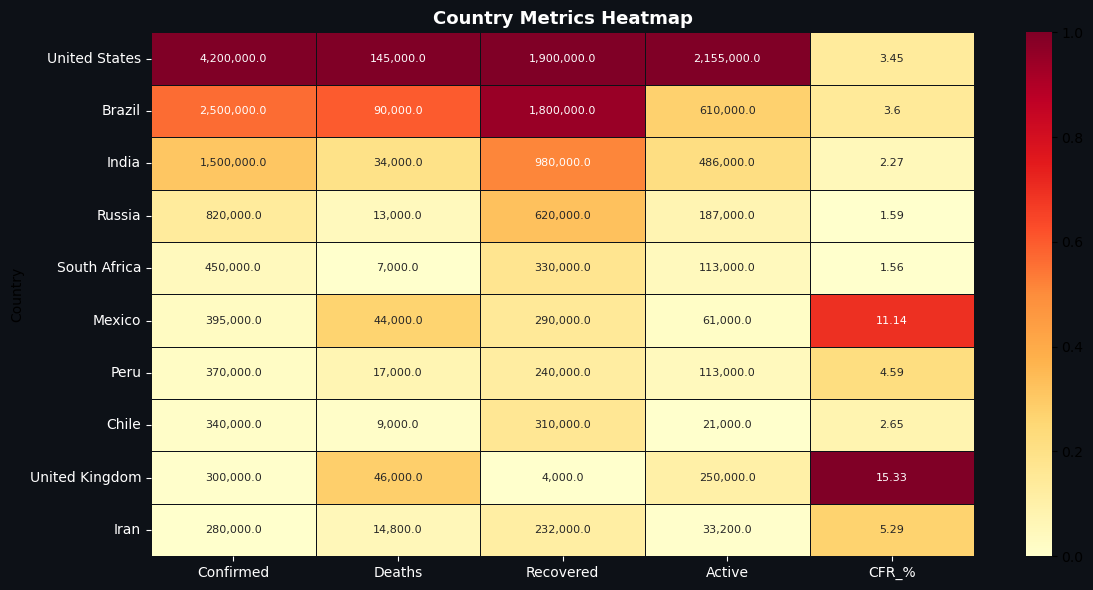

✅ Heatmap saved!


In [15]:
# Cell 10 — Heatmap
heat_data = df_top10[['Country','Confirmed','Deaths','Recovered','Active','CFR_%']].set_index('Country')
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min())

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0D1117')
sns.heatmap(heat_norm, annot=heat_data, fmt=',', cmap='YlOrRd',
            linewidths=0.5, linecolor='#0D1117',
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Country Metrics Heatmap', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('outputs/06_heatmap.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('✅ Heatmap saved!')

In [16]:
# Cell 11 — Export CSVs & Final Summary
df_top10.to_csv('outputs/covid_top10_countries.csv', index=False)
df_region.to_csv('outputs/covid_regional.csv', index=False)
df_ts.to_csv('outputs/covid_timeseries.csv', index=False)
df_wow.to_csv('outputs/covid_wow_growth.csv', index=False)

print('✅ All CSVs exported!')
print('=' * 50)
print(f'Total Confirmed : {TOTAL_CONFIRMED:>12,.0f}')
print(f'Total Deaths    : {TOTAL_DEATHS:>12,.0f}  ({TOTAL_DEATHS/TOTAL_CONFIRMED*100:.2f}%)')
print(f'Total Recovered : {TOTAL_RECOVERED:>12,.0f}  ({TOTAL_RECOVERED/TOTAL_CONFIRMED*100:.2f}%)')
print(f'Active Cases    : {TOTAL_ACTIVE:>12,.0f}  ({TOTAL_ACTIVE/TOTAL_CONFIRMED*100:.2f}%)')
print('=' * 50)
print('🎉 Dashboard pipeline complete!')

✅ All CSVs exported!
Total Confirmed :   16,480,000
Total Deaths    :      654,036  (3.97%)
Total Recovered :    9,470,000  (57.46%)
Active Cases    :    6,360,000  (38.59%)
🎉 Dashboard pipeline complete!
